## Example script to process ACTIVPAL data

[![Run in Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/luisfrancs/wealth_pb_ee_models/blob/main/examples/ActivePAL_Daily_prediction_AP_GITHUB-CLEAN.ipynb)

In [1]:
""" This script provides an example pipeline for predicting Physical Behaviour
(PB) and Energy Expenditure (EE) from activPAL wearable sensor data.

It supports both:
    - Uncompressed CSV files (.csv)
    - Compressed DATX files (.datx)

The script automatically detects the file format, loads the data, applies
a trained machine learning model, and outputs window-based predictions
for PB and EE.
This example is intended for research and demonstration purposes within
the WEALTH project framework.
"""

' This script provides an example pipeline for predicting Physical Behaviour\n(PB) and Energy Expenditure (EE) from activPAL wearable sensor data.\n\nIt supports both:\n    - Uncompressed CSV files (.csv)\n    - Compressed DATX files (.datx)\n\nThe script automatically detects the file format, loads the data, applies\na trained machine learning model, and outputs window-based predictions\nfor PB and EE.\nThis example is intended for research and demonstration purposes within\nthe WEALTH project framework.\n'

## Install the wealth_pb_ee_models package


In [3]:
import importlib.util
import glob, os

PKG = "wealth_pb_ee_models"
REPO = "wealth_pb_ee_models"
URL = "https://github.com/luisfrancs/wealth_pb_ee_models.git"

if importlib.util.find_spec(PKG) is None:
    if not os.path.isdir(REPO):
        !git clone {URL}
    %cd {REPO}
    %pip install -e . --config-settings editable_mode=compat
    %cd ..
else:
    print("Package already installed.")

Package already installed.


## Import functions and libraries

In [5]:
from wealth_pb_ee_models.models.pretrained_models import multi_taks_7classes_AP
from wealth_pb_ee_models.utils.utils import predict_single_file_AP
import matplotlib.pyplot as plt
import pandas as pd
from importlib.resources import files
import importlib.util
import re, gc
from pathlib import Path

## LOAD KERAS MODEL


In [6]:
loaded_model, encoding_dict_PB, encoding_dict_EE =multi_taks_7classes_AP()

In [7]:
encoding_dict_PB

{0: 'Sitting',
 1: 'Standing',
 2: 'Walking',
 3: 'Running',
 4: 'Sports',
 5: 'Cycling',
 6: 'Lying'}

In [8]:
encoding_dict_EE

{0: 'Sedentary', 1: 'LPA', 2: 'MVPA'}

# SINGLE FILE PREDICTION

In [9]:
# Get path to sample_data/activPAL folder
file_name = files("wealth_pb_ee_models.sample_data.activPAL") / "1221-AP170016 202a 14Aug23 3-00pm for 9d.datx"
file_name=str(file_name) #transform the path to string

In [10]:
#Predic PB and EE (it can load activPAL files: .datx (compressed) files and uncompresed .csv files)
df_predicted, accel_data = predict_single_file_AP(
    file_name, #Path to activPAL data file
    loaded_model, #Load trained model
    encoding_dict_PB, #Load Dictionnary for PB
    encoding_dict_EE) #Load Dictionnary for EE

153/153 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step


In [11]:
df_predicted

,Time,activity,Energy_expenditure
0,2023-08-14 14:59:52,Lying,Sedentary
1,2023-08-14 15:00:02,Lying,Sedentary
2,2023-08-14 15:00:12,Lying,Sedentary
3,2023-08-14 15:00:22,Lying,Sedentary
4,2023-08-14 15:00:32,Lying,Sedentary
...,...,...,...
78211,2023-08-23 16:15:02,Sitting,Sedentary
78212,2023-08-23 16:15:12,Sitting,Sedentary
78213,2023-08-23 16:15:22,Sitting,Sedentary
78214,2023-08-23 16:15:32,Sitting,Sedentary


## Daily spend time in different physical behaviours

In [12]:
#Import "wealth_pb_ee_models" utilities
from wealth_pb_ee_models.utils.utils_analytics import minutes_summary

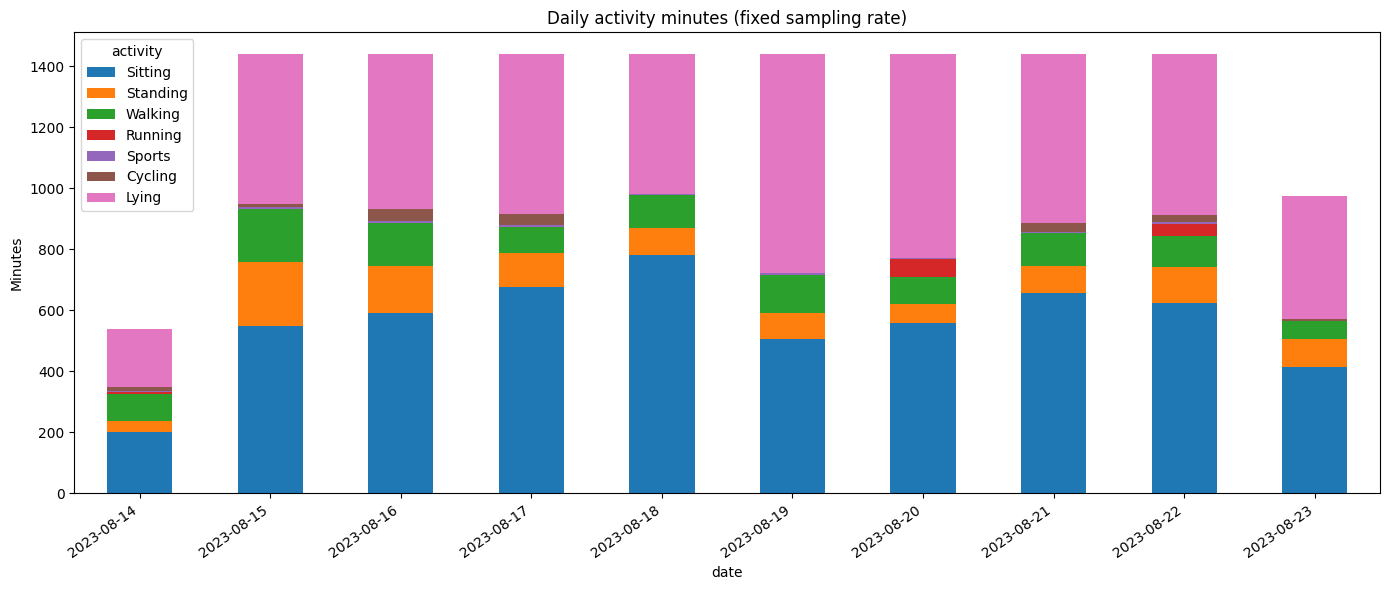

In [13]:
ACTIVITY_ORDER = ['Sitting', 'Standing', 'Walking', 'Running', 'Sports', 'Cycling','Lying']
minutes=minutes_summary(df_predicted,encoding_dict_PB,ACTIVITY_ORDER, analytics="activity", plot=True)

In [14]:
minutes = minutes.round(2)
minutes

,date,Sitting,Standing,Walking,Running,Sports,Cycling,Lying,daily_count
0,2023-08-14,199.50,37.17,88.83,5.17,6.00,10.83,192.67,540.17
1,2023-08-15,550.00,208.33,173.83,0.17,5.33,11.50,490.83,1440.00
2,2023-08-16,592.67,152.50,142.67,0.00,4.50,39.33,508.33,1440.00
3,2023-08-17,675.50,111.83,87.67,0.00,4.83,36.00,524.17,1440.00
4,2023-08-18,780.33,89.83,107.17,0.17,4.67,0.33,457.50,1440.00
5,2023-08-19,507.33,82.50,125.50,0.17,6.17,0.33,718.00,1440.00
6,2023-08-20,558.67,62.67,87.33,59.33,4.00,0.00,668.00,1440.00
7,2023-08-21,656.00,89.50,108.17,0.00,3.67,28.00,554.67,1440.00
8,2023-08-22,624.33,118.83,99.50,39.50,7.00,22.33,528.50,1440.00
9,2023-08-23,414.33,90.67,58.83,0.00,0.83,5.50,405.67,975.83


## Daily spend time in different levels of energy expenditure

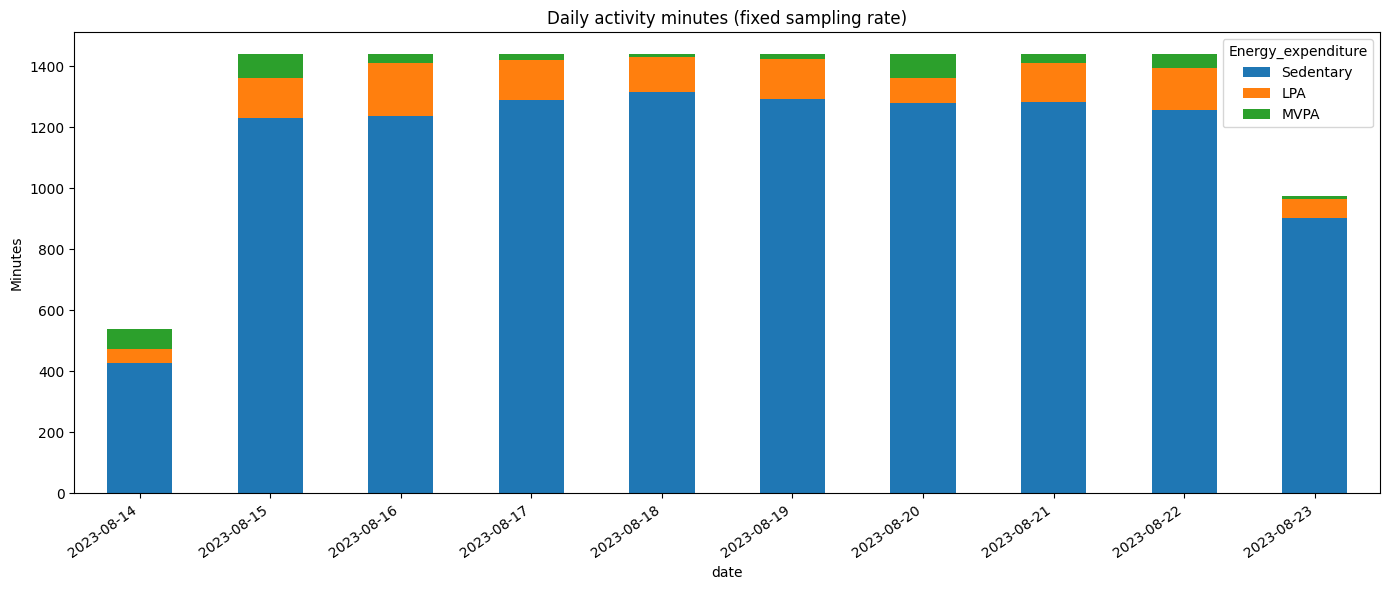

In [15]:
ACTIVITY_ORDER_EE = ['Sedentary', 'LPA', 'MVPA']
minutes_EE=minutes_summary(df_predicted,encoding_dict_EE,ACTIVITY_ORDER_EE, analytics="Energy_expenditure", plot=True)

In [16]:
minutes_EE

,date,Sedentary,LPA,MVPA,daily_count
0,2023-08-14,426.000000,48.833333,65.333333,540.166667
1,2023-08-15,1231.000000,132.833333,76.166667,1440.000000
2,2023-08-16,1236.333333,176.666667,27.000000,1440.000000
3,2023-08-17,1291.333333,130.833333,17.833333,1440.000000
4,2023-08-18,1314.833333,115.000000,10.166667,1440.000000
5,2023-08-19,1294.666667,130.166667,15.166667,1440.000000
6,2023-08-20,1278.833333,82.166667,79.000000,1440.000000
7,2023-08-21,1282.166667,128.833333,29.000000,1440.000000
8,2023-08-22,1257.833333,136.666667,45.500000,1440.000000
9,2023-08-23,903.500000,61.000000,11.333333,975.833333


# BATCH PROCESSING

## Batch Prediction


In [17]:
from importlib import resources
from pathlib import Path

with resources.path("wealth_pb_ee_models.sample_data", "activPAL") as activpal_path:
  path_AP_files = str(activpal_path)

In [18]:
# Step 1 – Predic PB and EE in all files stored in an specific folder
path_AP_files ="/content/wealth_pb_ee_models/src/wealth_pb_ee_models/sample_data/activPAL" # Folder of activePAL files (.datx or .csv)
out = Path("Predicted_AP_CSVs")
out.mkdir(exist_ok=True)
allFiles = glob.glob(path_AP_files + "/*.datx") #Filter files with specific extension

for file_ in allFiles:
    print(file_)
    df_predicted, _ = predict_single_file_AP(file_, loaded_model,encoding_dict_PB,encoding_dict_EE,batch_size=512)
    ID_num = re.search(r'\d+', os.path.basename(file_)).group(0)#get ID number
    # Save as CSV
    df_predicted.to_csv(out / f"{ID_num}_PB_EE_predicted_7class_multitask_AP.csv", index=False)
    del df_predicted
    gc.collect()#Clear memory

/content/wealth_pb_ee_models/src/wealth_pb_ee_models/sample_data/activPAL/1103-AP170004 202a 28Mar23 3-00pm for 9d.datx
153/153 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step
/content/wealth_pb_ee_models/src/wealth_pb_ee_models/sample_data/activPAL/1221-AP170016 202a 14Aug23 3-00pm for 9d.datx
153/153 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step


## Compute daily spend time in PB and EE as batch process

In [19]:
# Step 2 – Compute daily spend time in PB and EE and merges the resuults in a single dataframe

path =r'/content/Predicted_AP_CSVs' # Folder of Predicted_AP_CSVs
allFiles = glob.glob(path + "/*.csv") #Filter files with specific extension
dfs = [] #Create an empty space to store the single files results

for file_ in allFiles:
    print(file_)
    df_predicted = pd.read_csv(file_, sep=",")
    ID_num = re.search(r'\d+', os.path.basename(file_)).group(0)#get ID number
    minutes_PB=minutes_summary(df_predicted,encoding_dict_PB,ACTIVITY_ORDER,analytics="activity",plot=False)
    minutes_EE=minutes_summary(df_predicted,encoding_dict_EE,ACTIVITY_ORDER_EE, analytics="Energy_expenditure", plot=False)
    minutes_EE = minutes_EE.drop(columns=["daily_count", "date"])#remove repeated columns
    minutes_df = pd.concat([minutes_PB, minutes_EE], axis=1)
    # Insert subject ID in the first column
    minutes_df.insert(0, "ID", ID_num)
    dfs.append(minutes_df)#store partial results

df_all = pd.concat(dfs, ignore_index=True)#flatten all dfs in a single df

/content/Predicted_AP_CSVs/1103_PB_EE_predicted_7class_multitask_AP.csv
/content/Predicted_AP_CSVs/1221_PB_EE_predicted_7class_multitask_AP.csv


In [20]:
df_all = df_all.round(2)
df_all.head(12)

,ID,date,Sitting,Standing,Walking,Running,Sports,Cycling,Lying,daily_count,Sedentary,LPA,MVPA
0,1103,2023-03-28,266.00,68.67,72.33,4.83,1.50,4.50,122.33,540.17,453.17,61.67,25.33
1,1103,2023-03-29,642.00,50.50,43.67,0.00,3.00,0.00,700.83,1440.00,1388.00,49.83,2.17
2,1103,2023-03-30,698.17,55.17,52.83,0.00,1.83,0.33,631.67,1440.00,1380.67,58.67,0.67
3,1103,2023-03-31,452.17,98.00,109.50,12.50,7.00,0.50,760.33,1440.00,1305.00,109.17,25.83
4,1103,2023-04-01,519.83,99.83,68.50,0.00,3.17,0.33,748.33,1440.00,1362.00,74.67,3.33
5,1103,2023-04-02,552.83,80.00,130.33,0.00,2.67,0.17,674.00,1440.00,1304.83,82.67,52.50
6,1103,2023-04-03,424.33,147.33,128.67,1.83,8.67,0.17,729.00,1440.00,1289.00,144.67,6.33
7,1103,2023-04-04,839.33,142.83,93.83,0.00,1.17,0.17,362.67,1440.00,1339.00,95.33,5.67
8,1103,2023-04-05,695.67,76.17,54.83,0.00,2.67,0.17,610.50,1440.00,1375.83,57.33,6.83
9,1103,2023-04-06,393.33,17.17,17.83,0.00,1.00,0.17,549.50,979.00,957.17,20.83,1.00


In [21]:
# SAVE TABLE DAILY SUMMARY PER SUBJECT
#df_all.to_csv("DAILY_SUMMARY_PER_SUBJECT_TEST.csv", index=False)

## Data analytics on multiple files

In [22]:
from wealth_pb_ee_models.utils.utils_analytics import filter_valid_days,summarize_weekday_weekend_weighted, summarize_weekday_weekend
from wealth_pb_ee_models.utils.utils_analytics import plot_multiple_weighted_summaries, prepare_plot_data, plot_activity_bars

In [23]:
# Step 1 – Filter valid days per hour (≥ 8 hours)
df_valid = filter_valid_days(df_all, min_wear_hours=8)

In [24]:
# Step 2 – Summarise weekday vs weekend in a single value (WEIGTHED 2/5)
'''Summarise activity per participant using a weighted average. Weighting: Weekdays: 5/7; Weekends: 2/7'''
summary_weigthed_AP = summarize_weekday_weekend_weighted(df_valid,ACTIVITY_ORDER,ACTIVITY_ORDER_EE)
summary_weigthed_AP

,ID,Sitting_mean,Sitting_std,Standing_mean,Standing_std,Walking_mean,Walking_std,Running_mean,Running_std,Sports_mean,...,Cycling_mean,Cycling_std,Lying_mean,Lying_std,Sedentary_mean,Sedentary_std,LPA_mean,LPA_std,MVPA_mean,MVPA_std
0,1103,547.076429,145.880742,84.247143,36.348053,79.608750,38.795562,1.710714,3.160429,3.230714,...,0.608036,1.119270,602.014107,169.350765,1228.104286,245.715965,75.825357,29.618912,14.567679,17.339533
1,1221,553.416071,139.160952,100.976071,40.245035,107.785536,33.046233,12.518750,21.811926,4.741250,...,13.781071,10.339201,524.994643,93.507112,1166.124107,223.677823,113.428929,39.654685,38.660893,30.590906


## Averaged daily distribution of time spent in PB (Weighted summaries)

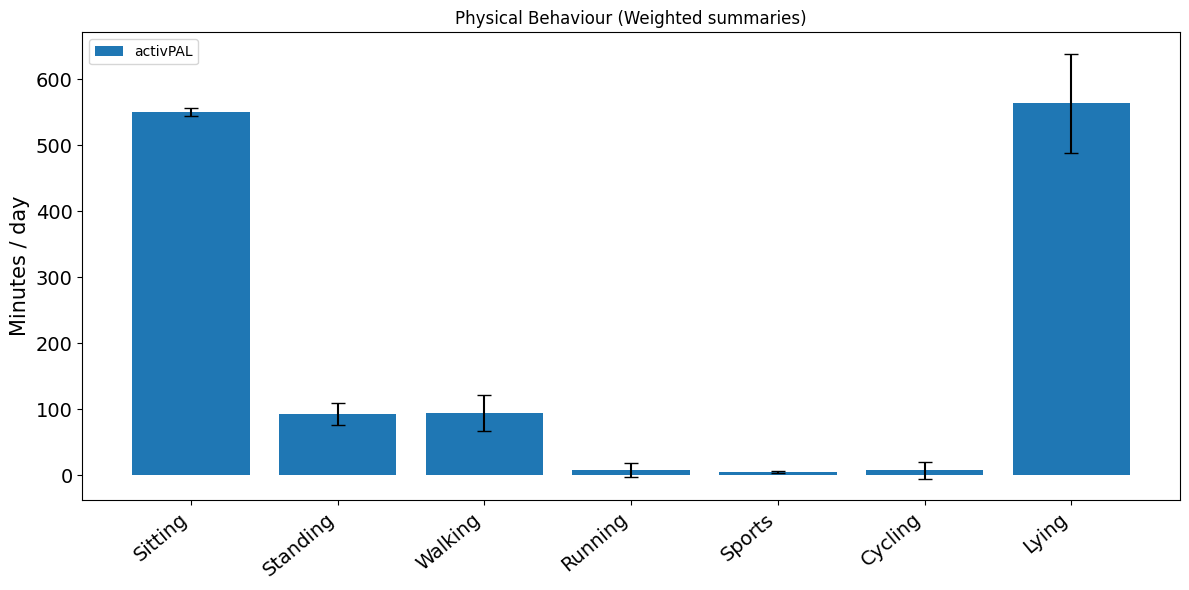

In [25]:
plot_multiple_weighted_summaries(
    summaries={ "activPAL":summary_weigthed_AP},
    variables=ACTIVITY_ORDER, title="Physical Behaviour (Weighted summaries)")

## Averaged daily distribution of time spent in EE (Weighted summaries)

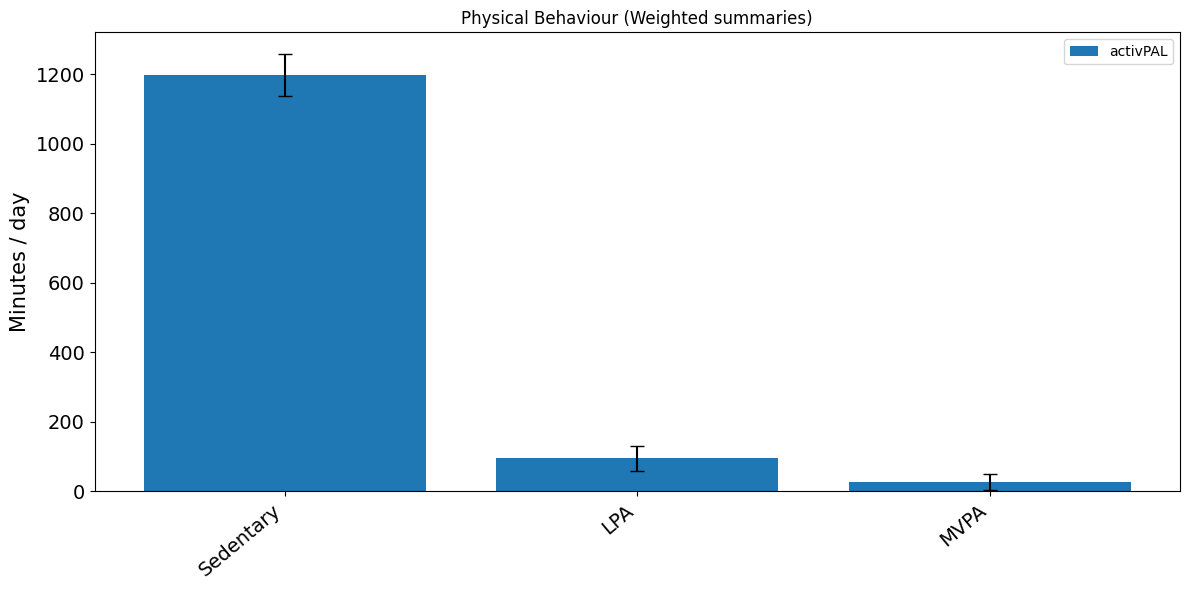

In [26]:
plot_multiple_weighted_summaries(
    summaries={ "activPAL":summary_weigthed_AP },
    variables=ACTIVITY_ORDER_EE, title="Physical Behaviour (Weighted summaries)")